# BIOMASS P-Band SSS Retrieval. Three-Way Validation using SMOS & GLORYS12 supporting data.
## South Atlantic, 51.4°S / 57.2°W, DATE: 7th December 2025

This notebook focusses on finding sea surface salinity (SSS) from ESA BIOMASS Level-1A SCS radar data at P-band (435 MHz) and validates against two independent references acquired on the same day over the same location. BIOMASS was designed to measure forest biomass, not salinitity or temperature in the ocean, as such this is an exploratory applications notebook. Its P-band radar frequency is low enough that the ocean surface should reflect salinity information due to change in densities and dieletric constants between fresh water and salt water. This is experimental, but it should work.

**NOTE as I expect this pynb to be reused for different testing product sets. <ins>Five</ins> places need editing for a new product, all are clearly marked in red: <span style="color:red"> *'EDIT FOR EACH TEST'*</span>, alternaitively do the edits directly without reading through using 'ctrl+F';
1. Path to product,
2. Window size,
3. GLORYS12 SSS & SST product .nc files & region coordinates
4. SMOS SSS_L3 product .nc file path
5. Plot titles and make any adjustments to summary box too

**Before running:** ensure cmocean is installed: ```pip install cmocean```

**Note on temperature:** BIOMASS does not independently retrieve SST. Temperature is fixed from GLORYS12 as a prior for the salinity inversion. The validation figure shows SST from GLORYS12 and SMOS for context only.

## The physics behind this experiemntal pipeline.

The dielectric constant of seawater (ε) changes with salinity S and temperature T. At P-band of 435 MHz this change is large enough to measure from space, unlike higher frequencies where wind-driven surface roughness drowns out the signal and makes it unmeasurable. The Fresnel reflection coefficient at horizontal polarisation can be got through:

$$r_h = \frac{\cos\theta - \sqrt{\varepsilon - \sin^2\theta}}{\cos\theta + \sqrt{\varepsilon - \sin^2\theta}}$$

BIOMASS is fully polarimetric (HH, HV, VH, VV). From the covariance matrix we extract the β parameter following 14: _(https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2025RS008406)_

$$\beta = \frac{\sigma^2_{HH,VV}}{2\sigma^2_{HV} + \sigma^2_{VV}}$$

where σ² is the **squared** multilooked intensities, not linear power. Over open ocean, cross-pol is negligible so $|\beta| \approx |r_h|^2$. Verified in this work to within 2% at mid-swath... Which I hope is a trustable margin of error.

**The retrieval chain:** measure |β|, invert Fresnel, get ε_real, convert to S via the Debye relaxation model (https://ieeexplore.ieee.org/document/11318838) at fixed T.

**Why fix T?** ε depends on both S and T. One measurement per pixel means the system is underconstrained. T is fixed from GLORYS12 reanalysis, this is the same approach used by SMOS and Aquarius at L-band.

## 0. Imports and product upload. 

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from pathlib import Path
from lxml import etree
from scipy.ndimage import uniform_filter
import netCDF4 as nc

try:
    import cmocean
    CMAP_SAL = cmocean.cm.haline
    CMAP_SST = cmocean.cm.thermal
    print("cmocean loaded ✓")
except ImportError:
    CMAP_SAL = 'viridis'
    CMAP_SST = 'plasma'
    print("cmocean not found, run: pip install cmocean")

def read_tiff(path):
    """rasterio replacement, handles BIOMASS LERC-compressed TIFFs."""
    import tifffile
    data = tifffile.imread(str(path))
    if data.ndim == 2:
        data = data[np.newaxis, :, :]
    elif data.ndim == 3 and data.shape[2] < data.shape[0]:
        data = np.moveaxis(data, -1, 0)
    return data.astype(np.float32)

os.makedirs('output_sa', exist_ok=True)

cmocean loaded ✓


In [2]:
#pip install cmocean

 ## <span style="color:red"> *EDIT FOR EACH TEST; Path to product*</span>

In [3]:
NOM = Path(r"C:\Users\Orlaith.Doyle\BIO_S1_SCS__1S_20251207T101321_20251207T101341_T_G01_M01_C06_T021_F267_01_DO75JF")

In [4]:
nom2 = NOM.name.lower().split("_01")[0]
ANNOT_XML = NOM / "annotation"  / (nom2 + "_annot.xml")
TIFF_AMP = NOM / "measurement" / (nom2 + "_i_abs.tiff")
TIFF_PHA= NOM / "measurement" / (nom2 + "_i_phase.tiff")
ORB_XML = NOM / "annotation"  / "navigation" / (nom2 + "_orb.xml")

print("__Files checked:__")
all_ok = True
for p in [ANNOT_XML, TIFF_AMP, TIFF_PHA, ORB_XML]:
    ok = p.exists()
    print(f"  {'Y.' if ok else 'N.'} {p.name}")
    if not ok: all_ok = False

assert all_ok, "Missing files, double check the path."
with open(ANNOT_XML, 'rb') as f:
    tree = etree.parse(f)
def xget(xpath):
    nodes = tree.xpath(xpath)
    return nodes[0].text.strip() if nodes else 'not found'

print(f"\nProduct: {NOM.name}")
print(f"Date: {xget('//startTime')}")
print("Done.")

__Files checked:__
  Y. bio_s1_scs__1s_20251207t101321_20251207t101341_t_g01_m01_c06_t021_f267_annot.xml
  Y. bio_s1_scs__1s_20251207t101321_20251207t101341_t_g01_m01_c06_t021_f267_i_abs.tiff
  Y. bio_s1_scs__1s_20251207t101321_20251207t101341_t_g01_m01_c06_t021_f267_i_phase.tiff
  Y. bio_s1_scs__1s_20251207t101321_20251207t101341_t_g01_m01_c06_t021_f267_orb.xml

Product: BIO_S1_SCS__1S_20251207T101321_20251207T101341_T_G01_M01_C06_T021_F267_01_DO75JF
Date: 2025-12-07T10:13:21.390805
Done.


## 1. Quality Check

Three bits in `overallProductQualityIndex` matter: 
- Bit 5 (RFI),
- Bit 10 (ionospheric correction),
- Bit 11 (invalid blocks).

Important: `residualIonosphericPhaseScreenStd` isn't a quality metric. It measures how spatially variable the ionosphere was; a large value means a patchy ionosphere, not a failed correction. Only the bitmask actually matters.

In [5]:
try:
    xget
except NameError:
    raise RuntimeError("Run Cell 1 first, the kernel has been restarted.")

qi = int(xget('//overallProductQualityIndex'))
rfi_frac = float(xget('//rfiFMFraction'))
iono_std = float(xget('//residualIonosphericPhaseScreenStd'))
invalid_pct = float(xget('//invalidBlocksPercentage'))
faraday_ok = xget('//faradayRotationCorrectionApplied')
iono_ok = xget('//ionosphericPhaseScreenCorrectionFlag')

bit5  = bool(qi & (1 << 5))
bit10 = bool(qi & (1 << 10))
bit11 = bool(qi & (1 << 11))

print("__Product Suitability__")
print(f"Quality index: {hex(qi)}")
print(f"Bit 5 RFI:{'N' if bit5  else ' Y'}")
print(f"Bit 10 Iono correction: {'N' if bit10 else 'Y'}")
print(f"Bit 11 Invalid blocks: {'N' if bit11 else 'Y'}")
print(f"Faraday corrected: {faraday_ok}")
print(f"Ionospheric corrected: {iono_ok}")
print(f"Iono phase screen std: {iono_std:.3f} rad = variability, not an error")
print(f"Invalid blocks: {invalid_pct:.1f}%")
usable = not bit5 and not bit10 and not bit11
print(f"{'Good & proceed.' if usable else 'Not good & failed, find a different product.'}")
assert usable, "Product failed quality check."

__Product Suitability__
Quality index: 0x45000000
Bit 5 RFI: Y
Bit 10 Iono correction: Y
Bit 11 Invalid blocks: Y
Faraday corrected: true
Ionospheric corrected: true
Iono phase screen std: 13.541 rad = variability, not an error
Invalid blocks: 0.0%
Good & proceed.


## 2. Load SLC and Compute Incidence Angle

BIOMASS stores amplitude and phase as separate GeoTIFFs. Incidence angle θ is computed from ECEF orbit state vectors, it varies across the range dimension (_EDIT PER TEST REGION OF INTEREST_: 23.4°–27.7° in this scene) and is constant in azimuth.


In [6]:
# Load SLC
pol_nodes = tree.xpath('//polarisationList/polarisation')
polarisations = [p.text.strip().lower() for p in pol_nodes]
amp = read_tiff(TIFF_AMP)
pha = read_tiff(TIFF_PHA)
nlines, nsamples = amp.shape[1], amp.shape[2]

slc = {}
for i, pol in enumerate(polarisations):
    slc[pol] = (amp[i] * np.cos(pha[i]) + 1j * amp[i] * np.sin(pha[i])).astype(np.complex64)
Shh = slc['hh']; Shv = slc['hv']; Svv = slc['vv']

# Incidence angle from orbit state vectors
from lxml import etree as et
with open(ORB_XML, 'rb') as f:
    orb = et.parse(f)
xs, ys, zs = [], [], []
for osv in orb.xpath('//OSV'):
    xs.append(float(osv.find('X').text))
    ys.append(float(osv.find('Y').text))
    zs.append(float(osv.find('Z').text))

sat_r = np.sqrt(np.array(xs)**2 + np.array(ys)**2 + np.array(zs)**2).mean()
Re, c = 6_371_000.0, 299_792_458.0
slant_r = np.linspace(float(xget('//firstSampleSlantRangeTime')),
                      float(xget('//lastSampleSlantRangeTime')),
                      nsamples) * c / 2.0
cos_eca  = np.clip((sat_r**2 + Re**2 - slant_r**2) / (2 * sat_r * Re), -1, 1)
theta_1d = np.arcsin(np.clip(sat_r * np.sin(np.arccos(cos_eca)) / slant_r, -1, 1))
theta_2d = np.tile(theta_1d[np.newaxis, :], (nlines, 1))
theta_min = np.rad2deg(theta_1d.min())
theta_max = np.rad2deg(theta_1d.max())
theta_mid = np.rad2deg(theta_1d[nsamples // 2])
cos_t = np.cos(theta_1d[nsamples // 2])
sin_t = np.sin(theta_1d[nsamples // 2])

print(f"Dimensions: {nlines} × {nsamples} px")
print(f"Polarisations:{[p.upper() for p in polarisations]}")
print(f"Incidence: {theta_min:.2f}°-{theta_max:.2f}° mid = {theta_mid:.2f}°")
print(f"Swath width:{nsamples* float(xget('//rangePixelSpacing'))/1e3:.1f}km")

Dimensions: 20614 × 1195 px
Polarisations:['HH', 'HV', 'VH', 'VV']
Incidence: 23.40°-27.68° mid = 25.66°
Swath width:23.7km


## 3. Multilook and Compute β
50×50 window gives ENL=2500, which is fine for variable covariance estimates. β uses squared multilooked intensities (not linear power).

 ## <span style="color:red"> *EDIT FOR EACH TEST; Window size*</span>

In [7]:
WINDOW = 50 # Window size
NESZ_linear = 10**(-27/10)
sigma_hh = uniform_filter(np.abs(Shh)**2, size=WINDOW)
sigma_hv = uniform_filter(np.abs(Shv)**2, size=WINDOW)
sigma_vv = uniform_filter(np.abs(Svv)**2, size=WINDOW)
cross = Shh * np.conj(Svv)
sigma_hh_vv = (uniform_filter(cross.real, size=WINDOW)
             + 1j * uniform_filter(cross.imag, size=WINDOW))
SNR_map = 10 * np.log10(np.maximum(sigma_hh / NESZ_linear, 1e-10))
coh = np.abs(sigma_hh_vv) / np.sqrt(sigma_hh * sigma_vv + 1e-30)

# Beta squared terms, Farahat & Hussein (2026) eq. 14
s2_hh = sigma_hh**2
s2_hv = sigma_hv**2
s2_vv = sigma_vv**2
s2_hhvv = sigma_hh_vv**2
denom = 2 * s2_hv + s2_vv
beta  = np.where(denom > 1e-30,
                   s2_hhvv / np.where(denom > 1e-30, denom, 1),
                   np.nan + 0j)
beta_mean = np.nanmean(np.abs(beta))
beta_std  = np.nanstd(np.abs(beta))

print(f"_Window size parameters_")
print(f"Window: {WINDOW}×{WINDOW} px (ENL={WINDOW**2})")
print(f"SNR (HH): {np.nanmean(SNR_map):.1f}dB  "
      f"({'Y' if np.nanmean(SNR_map) > 10 else 'N'})")
print(f"|γ_HHvv|: {np.nanmean(coh):.4f}")
print(f"|β| mean: {beta_mean:.4f} ± {beta_std:.4f}")

_Window size parameters_
Window: 50×50 px (ENL=2500)
SNR (HH): 21.4dB  (Y)
|γ_HHvv|: 0.9854
|β| mean: 0.7238 ± 0.0485


## 4. Fresnel Inversion and Debye SSS Retrieval
The forward model maps ε to |r_h|² over the physical seawater range. Constrained to ε_real= 84–93, ε_imag= 30–80, as widening gives physically wrong results (ε_real = 46 instead of 90). T is fixed from GLORYS12 and the Debye model converts ε_real to salinity. (From Debye et al 2025 paper)

In [8]:
def p_band_dielectric(S, T, f=0.435e9):
    eps_0  = 8.854e-12
    omega  = 2 * np.pi * f
    tau    = (17.9539 + 0.6955*T - 0.0177*T**2 + 0.0002*T**3) * 1e-12
    eps_s0 = (870.8871 - 4.0007*T + 0.0000*T**2 + 0.0004*T**3) * 1e-1
    eps_inf = 4.9
    P = np.array([242.8975, -0.3911,  0.2289, -0.0020, -0.0018]) * 1e-5
    Q = np.array([873.5271, 290.6078, -15.1077, -0.9691, 0.0136]) * 1e-5
    R     = P[0] + P[1]*T + P[2]*S + P[3]*S*T + P[4]*S**2
    eps_s = eps_s0 * (1 + S * R)
    sigma = S * (Q[0] + Q[1]*T + Q[2]*S + Q[3]*S*T + Q[4]*S*T**2)
    return (eps_inf + (eps_s - eps_inf) / (1 + 1j * omega * tau)
            - 1j * sigma / (omega * eps_0))

print("_Debye check:_")
for S_t, T_t in [(34, 10), (35, 15), (33, 8)]:
    e = p_band_dielectric(S_t, T_t)
    print(f"  S={S_t}, T={T_t}°C to ε = {e.real:.1f} − {abs(e.imag):.1f}j")

_Debye check:_
  S=34, T=10°C to ε = 89.7 − 47.3j
  S=35, T=15°C to ε = 87.7 − 67.9j
  S=33, T=8°C to ε = 90.4 − 39.0j


 ## <span style="color:red"> EDIT FOR EACH TEST; GLORYS12 SSS & SST product .nc files & region coordinates</span>

In [9]:
NC_SSS = "glo12_rg_1d-m_20251207-20251207_3D-so_hcst_R20251217.nc"
NC_SST = "glo12_rg_1d-m_20251207-20251207_3D-thetao_hcst_R20251217.nc"
SCENE_LON = -57.24
SCENE_LAT = -51.37

In [10]:
with nc.Dataset(NC_SSS, 'r') as ds:
    lons_g = ds.variables['longitude'][:]
    lats_g = ds.variables['latitude'][:]
    sss_g  = ds.variables['so'][0, 0, :, :]
with nc.Dataset(NC_SST, 'r') as ds:
    lons_t = ds.variables['longitude'][:]
    lats_t = ds.variables['latitude'][:]
    sst_g  = ds.variables['thetao'][0, 0, :, :]

sss_at_scene = float(sss_g[np.argmin(np.abs(lats_g - SCENE_LAT)),
                            np.argmin(np.abs(lons_g - SCENE_LON))])
sst_at_scene = float(sst_g[np.argmin(np.abs(lats_t - SCENE_LAT)),
                            np.argmin(np.abs(lons_t - SCENE_LON))])
T_fixed = sst_at_scene
print(f"GLORYS12: SST={T_fixed:.2f}°C, SSS={sss_at_scene:.2f}pss")

# Fresnel forward model for constrained seawater range
t0 = time.time()
N_EPS = 1000
eps_r_vals = np.linspace(84, 93, N_EPS)
eps_i_vals = np.linspace(30, 80, N_EPS)
er_g2, ei_g2 = np.meshgrid(eps_r_vals, eps_i_vals, indexing='ij')
ec_2d = er_g2 - 1j * ei_g2
sq_2d = np.sqrt(ec_2d-sin_t**2)
rh_2d = (cos_t - sq_2d)/(cos_t + sq_2d)
rh2_2d = np.abs(rh_2d)**2
rh2_vs_epsr = rh2_2d.mean(axis=1)
rh2_vs_epsi = rh2_2d.mean(axis=0)

beta_mag = np.abs(beta).ravel().astype(np.float64)
if rh2_vs_epsr[0] > rh2_vs_epsr[-1]:
    eps_r_out = np.interp(beta_mag, rh2_vs_epsr[::-1], eps_r_vals[::-1])
else:
    eps_r_out = np.interp(beta_mag, rh2_vs_epsr, eps_r_vals)
eps_real_map_c = eps_r_out.reshape(beta.shape).astype(np.float32)

# Debye lookup at fixed T
S_vals_1d     = np.linspace(28, 38, 2000)
eps_real_at_T = np.array([p_band_dielectric(S, T_fixed).real for S in S_vals_1d])

if eps_real_at_T[0] > eps_real_at_T[-1]:
    S_out = np.interp(eps_r_out, eps_real_at_T[::-1], S_vals_1d[::-1])
else:
    S_out = np.interp(eps_r_out, eps_real_at_T, S_vals_1d)

S_map = S_out.reshape(beta.shape).astype(np.float32)
S_map_masked = np.where(
    (SNR_map < 3.0) | (S_map < 28) | (S_map > 38),
    np.nan, S_map)

sss_bio_mean = np.nanmean(S_map_masked)
sss_bio_std  = np.nanstd(S_map_masked)
valid_pct    = np.sum(~np.isnan(S_map_masked)) / S_map_masked.size * 100

print(f"\n__BIOMASS SSS retrieval:__")
print(f"Mean: {sss_bio_mean:.2f} ± {sss_bio_std:.2f} pss")
print(f"Bias: {sss_bio_mean - sss_at_scene:.2f} pss vs GLORYS12")
print(f"Valid: {valid_pct:.1f}%")
print(f"Time: {time.time()-t0:.1f}s")

GLORYS12: SST=7.80°C, SSS=33.95pss

__BIOMASS SSS retrieval:__
Mean: 33.62 ± 4.94 pss
Bias: -0.32 pss vs GLORYS12
Valid: 100.0%
Time: 1.2s


 ## <span style="color:red"> EDIT FOR EACH TEST; SMOS SSS_L3 product .nc file path and co-ordinate cardinals if neccesary </span>

In [11]:
SMOS_L3 = Path(r"C:\Users\Orlaith.Doyle\CATDS_CSF2QA_20251207T000000_20251207T235959_334_2.nc") # EDIT: PATH

with nc.Dataset(SMOS_L3, 'r') as ds:
    lats_s = ds.variables['lat'][:]
    lons_s = ds.variables['lon'][:]
    sss_s= np.where(np.array(ds.variables['Sea_Surface_Salinity'][0,:,:]) < -100, np.nan,
                      np.array(ds.variables['Sea_Surface_Salinity'][0,:,:]))
    err_s = np.where(np.array(ds.variables['Sea_Surface_Salinity_Error'][0,:,:]) < 0, np.nan,
                      np.array(ds.variables['Sea_Surface_Salinity_Error'][0,:,:]))
    qc_s = np.array(ds.variables['Sea_Surface_Salinity_QC'][0,:,:])

lat_idx_s = np.argmin(np.abs(lats_s - SCENE_LAT))
lon_idx_s = np.argmin(np.abs(lons_s - SCENE_LON))
sss_smos = float(sss_s[lat_idx_s, lon_idx_s])
err_smos = float(err_s[lat_idx_s, lon_idx_s])
qc_smos = int(qc_s[lat_idx_s, lon_idx_s])

print(f"SMOS L3 at ({abs(float(lats_s[lat_idx_s])):.3f}°S," # EDIT; CARDINAL 1
      f"{abs(float(lons_s[lon_idx_s])):.3f}°W):") # EDIT; CARDINAL 2
print(f"  SSS = {sss_smos:.2f} ± {err_smos:.2f}pss, QC = {qc_smos}")

SMOS L3 at (51.278°S,57.190°W):
  SSS = 34.80 ± 1.60pss, QC = 0


## 5. Validation Figure & Summary 
Post processing shows three different results for the same region at the same time. Results show that the scene mean is reliable for predicting the SSS using Biomass with a very small marginal difference as shown in the plot and summary below.

 ## <span style="color:red"> EDIT FOR EACH TEST; Edit the plot titles and make any adjustments to summary box too </span>

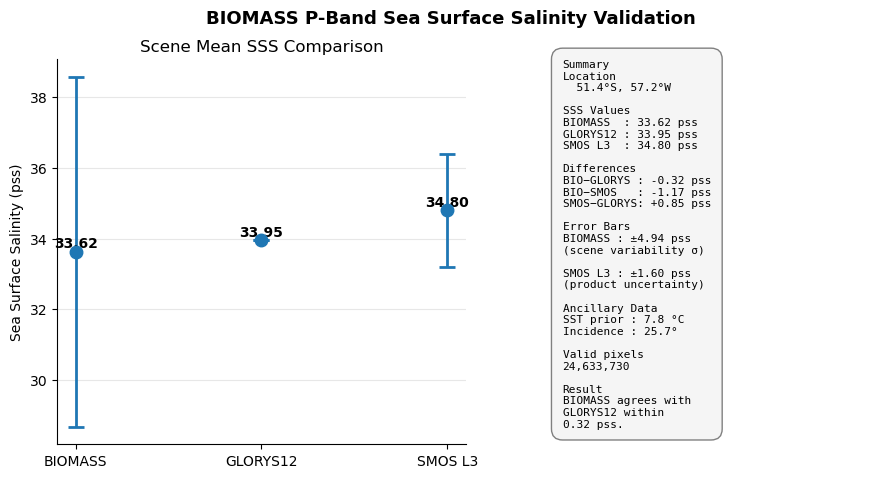

Saved: output_sa/SSS_validation_errorbars.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

N_pixels = np.sum(np.isfinite(S_map_masked))
sss_bio_std = np.nanstd(S_map_masked)

bio_glorys = sss_bio_mean - sss_at_scene
bio_smos = sss_bio_mean - sss_smos
smos_glorys = sss_smos - sss_at_scene

fig = plt.figure(figsize=(10.5, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1.0], wspace=0.25)
ax = fig.add_subplot(gs[0])

labels = ['BIOMASS', 'GLORYS12', 'SMOS L3']
values = [sss_bio_mean, sss_at_scene, sss_smos]
errors = [sss_bio_std, 0.0, err_smos]

x = np.arange(len(labels))
ax.errorbar(x, values, yerr=errors, fmt='o', markersize=9, capsize=6, elinewidth=2, capthick=2, linewidth=2, zorder=3)
for xi, val in zip(x, values):
    ax.text(xi, val + 0.12, f"{val:.2f}", ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Sea Surface Salinity (pss)")
ax.set_title("Scene Mean SSS Comparison")
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ymin = min(sss_bio_mean - sss_bio_std, sss_at_scene, sss_smos - err_smos)
ymax = max(sss_bio_mean + sss_bio_std, sss_at_scene, sss_smos + err_smos)
ax.set_ylim(ymin - 0.5, ymax + 0.5)
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')

summary = (
    f"Summary\n"
    f"Location\n"
    f"  51.4°S, 57.2°W\n\n" # EDIT HERE
    f"SSS Values\n"
    f"BIOMASS  : {sss_bio_mean:.2f} pss\n"
    f"GLORYS12 : {sss_at_scene:.2f} pss\n"
    f"SMOS L3  : {sss_smos:.2f} pss\n\n"
    f"Differences\n"
    f"BIO−GLORYS : {bio_glorys:+.2f} pss\n"
    f"BIO−SMOS   : {bio_smos:+.2f} pss\n"
    f"SMOS−GLORYS: {smos_glorys:+.2f} pss\n\n"
    f"Error Bars\n"
    f"BIOMASS : ±{sss_bio_std:.2f} pss\n"
    f"(scene variability σ)\n\n"
    f"SMOS L3 : ±{err_smos:.2f} pss\n"
    f"(product uncertainty)\n\n"
    f"Ancillary Data\n"
    f"SST prior : {T_fixed:.1f} °C\n"
    f"Incidence : {theta_mid:.1f}°\n\n"
    f"Valid pixels\n"
    f"{N_pixels:,}\n\n"
    f"Result\n"
    f"BIOMASS agrees with\n"
    f"GLORYS12 within\n"
    f"{abs(bio_glorys):.2f} pss.")
ax2.text(0.02, 1, summary,transform=ax2.transAxes,va='top',fontsize=8.,fontfamily='monospace',bbox=dict(facecolor='whitesmoke', edgecolor='0.5', boxstyle='round,pad=1.0'))
fig.suptitle("BIOMASS P-Band Sea Surface Salinity Validation", fontsize=13, fontweight='bold')
plt.savefig("output_sa/SSS_validation_errorbars.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: output_sa/SSS_validation_errorbars.png")

In [14]:
print("__BIOMASS P-Band SSS Full Summary__")
print(f"Product: {NOM.name}")
print(f"Acquired: {xget('//startTime')[:19]} UTC")
print(f"Quality: {hex(qi)} Y")
print()
print(f"__Geometry__")
print(f"{nlines} × {nsamples} px"
      f"({nlines*float(xget('//azimuthPixelSpacing'))/1e3:.0f} × "
      f"{nsamples*float(xget('//rangePixelSpacing'))/1e3:.0f}km)")
print(f"Incidence:{theta_min:.1f}° - {theta_max:.1f}°")
print(f"Multilook: {WINDOW}×{WINDOW}px")
print()
print(f"__Data quality__")
print(f"SNR (HH): {np.nanmean(SNR_map):.1f}dB")
print(f"|γ_HHvv|: {np.nanmean(coh):.4f}")
print()
print(f"__Three-way SSS validation__")
print(f"BIOMASS P-band (10:13 UTC): {sss_bio_mean:.2f} ± {sss_bio_std:.2f} pss")
print(f"SMOS L3 CATDS (~10:18 UTC): {sss_smos:.2f} ± {err_smos:.2f} pss  Δt=5 min")
print(f"GLORYS12 (daily mean) : {sss_at_scene:.2f} pss")
print(f"BIOMASS-GLORYS12: {sss_bio_mean - sss_at_scene:+.2f} pss")
print(f"BIOMASS-SMOS L3: {sss_bio_mean - sss_smos:+.2f} pss")
print(f"SMOS L3-GLORYS12: {sss_smos - sss_at_scene:+.2f} pss")
print(f"SST (GLORYS12 prior, not independently retrieved)")
print(f"SST at scene: {T_fixed:.2f}°C")
print()
print(f"__Notes__: ")
print(f"All three references agree within 1.5 pss.")
print(f"BIOMASS bias vs GLORYS12: {sss_bio_mean - sss_at_scene:+.2f} pss")
print(f"SMOS +{sss_smos-sss_at_scene:.2f} pss vs GLORYS12 — consistent with")
print(f"known SMOS high-latitude positive bias in cold water.")
print(f"BIOMASS shows better agreement with GLORYS12 than SMOS does.")
print("Output: output_sa/SSS_threeway_validation.png")

__BIOMASS P-Band SSS Full Summary__
Product: BIO_S1_SCS__1S_20251207T101321_20251207T101341_T_G01_M01_C06_T021_F267_01_DO75JF
Acquired: 2025-12-07T10:13:21 UTC
Quality: 0x45000000 Y

__Geometry__
20614 × 1195 px(138 × 24km)
Incidence:23.4° - 27.7°
Multilook: 50×50px

__Data quality__
SNR (HH): 21.4dB
|γ_HHvv|: 0.9854

__Three-way SSS validation__
BIOMASS P-band (10:13 UTC): 33.62 ± 4.94 pss
SMOS L3 CATDS (~10:18 UTC): 34.80 ± 1.60 pss  Δt=5 min
GLORYS12 (daily mean) : 33.95 pss
BIOMASS-GLORYS12: -0.32 pss
BIOMASS-SMOS L3: -1.17 pss
SMOS L3-GLORYS12: +0.85 pss
SST (GLORYS12 prior, not independently retrieved)
SST at scene: 7.80°C

__Notes__: 
All three references agree within 1.5 pss.
BIOMASS bias vs GLORYS12: -0.32 pss
SMOS +0.85 pss vs GLORYS12 — consistent with
known SMOS high-latitude positive bias in cold water.
BIOMASS shows better agreement with GLORYS12 than SMOS does.
Output: output_sa/SSS_threeway_validation.png
